# 00 — Parameter Recovery

This notebook assesses parameter identifiability for all four candidate models (M1–M4) via parameter recovery analyses. Synthetic datasets (N = 100) were generated by sampling parameters from prior distributions and simulating choices using the Session 1 task structure. Each dataset was fitted using the same procedure as the empirical data. Recovery quality is evaluated via Pearson correlations and normalised RMSE between true and recovered subject-level parameter estimates.

**Outputs:**
- Table S2: Parameter recovery (Pearson r and normalised RMSE) across models
- Figure S2: Parameter recovery scatter plots for M4
- Figure S3: Pairwise correlations between recovered M4 parameters

## 1 — Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Directories
ANALYSIS_DIR = os.getcwd()
SIM_DIR      = os.path.join(ANALYSIS_DIR, 'data', 'simulated')
RECOVERY_DIR = os.path.join(ANALYSIS_DIR, 'stan_results', 'recovery')
FIG_DIR      = os.path.join(ANALYSIS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Colours
labelcolor = '#505050'
tickcolor  = '#606060'
axiscolor  = '#d3d3d3'
COLOR_REW  = '#234f81'
COLOR_PUN  = '#812623'
COLOR_OTH  = '#505050'

# Plot style
sns.set_theme(style='ticks', context='paper', font_scale=1.0)
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'font.size': 9
})

# Parameter definitions
PARAMS_BY_MODEL = {
    'pgng_m1': ['b1', 'b2', 'b3', 'b4', 'a1', 'a2'],
    'pgng_m2': ['b1', 'b2', 'b3', 'b4', 'a1', 'a2', 'd1', 'd2'],
    'pgng_m3': ['b1', 'b2', 'b3', 'b4', 'a1', 'a2', 'c1'],
    'pgng_m4': ['b1', 'b2', 'b3', 'b4', 'a1', 'a2', 'd1', 'd2', 'c1'],
}
ALL_PARAMS = ['b1', 'b2', 'b3', 'b4', 'a1', 'a2', 'd1', 'd2', 'c1']

PARAM_LABELS = {
    'b1': r'$\beta_+$', 'b2': r'$\beta_-$',
    'b3': r'$\tau_+$',  'b4': r'$\tau_-$',
    'a1': r'$\eta_+$',  'a2': r'$\eta_-$',
    'd1': r'$\delta_+$','d2': r'$\delta_-$',
    'c1': r'$\xi$',
}

print('Setup complete.')
print(f'SIM_DIR exists:      {os.path.exists(SIM_DIR)}')
print(f'RECOVERY_DIR exists: {os.path.exists(RECOVERY_DIR)}')

Setup complete.
SIM_DIR exists:      True
RECOVERY_DIR exists: True


## 2 — Load recovery results and compute Pearson r and Normalised RMSE

In [2]:
def load_subject_params(summary_path, param):
    """Load subject-level posterior means from Stan summary file."""
    summary = pd.read_csv(summary_path, sep='\t', index_col=0)
    rows    = summary.filter(regex=rf'^{param}\[', axis=0)
    return rows['Mean'].values

# Load results for all models
results = {}
for model, params in PARAMS_BY_MODEL.items():
    true_params  = pd.read_csv(os.path.join(SIM_DIR, f'true_params_{model}.csv'))
    summary_path = os.path.join(RECOVERY_DIR, f'{model}_summary.tsv')
    results[model] = {}
    for param in params:
        true_vals      = true_params[param].values
        recovered_vals = load_subject_params(summary_path, param)
        n = min(len(true_vals), len(recovered_vals))
        results[model][param] = {
            'true':      true_vals[:n],
            'recovered': recovered_vals[:n],
        }

# Build recovery tables
recovery_r    = {}
recovery_nrmse = {}

for model, params in PARAMS_BY_MODEL.items():
    recovery_r[model]     = {}
    recovery_nrmse[model] = {}
    for param in ALL_PARAMS:
        if param not in params:
            recovery_r[model][param]     = '—'
            recovery_nrmse[model][param] = '—'
        else:
            t    = results[model][param]['true']
            r    = results[model][param]['recovered']
            corr, _ = pearsonr(t, r)
            rmse    = np.sqrt(np.mean((t - r)**2))
            nrmse   = rmse / np.std(t)
            recovery_r[model][param]     = f'{corr:.3f}'
            recovery_nrmse[model][param] = f'{nrmse:.3f}'

df_r     = pd.DataFrame(recovery_r).rename(columns={
    'pgng_m1': 'M1', 'pgng_m2': 'M2', 'pgng_m3': 'M3', 'pgng_m4': 'M4'})
df_nrmse = pd.DataFrame(recovery_nrmse).rename(columns={
    'pgng_m1': 'M1', 'pgng_m2': 'M2', 'pgng_m3': 'M3', 'pgng_m4': 'M4'})

df_r.index     = [PARAM_LABELS[p] for p in ALL_PARAMS]
df_nrmse.index = [PARAM_LABELS[p] for p in ALL_PARAMS]

print('=== Table S2: Parameter Recovery (Pearson r) ===')
print(df_r.to_string())
print('\n=== Normalised RMSE ===')
print(df_nrmse.to_string())

=== Table S2: Parameter Recovery (Pearson r) ===
               M1     M2     M3     M4
$\beta_+$   0.031  0.134  0.014  0.199
$\beta_-$   0.707  0.915  0.734  0.826
$\tau_+$    0.889  0.892  0.861  0.924
$\tau_-$    0.917  0.975  0.960  0.965
$\eta_+$    0.206  0.631  0.583  0.650
$\eta_-$    0.460  0.344  0.864  0.738
$\delta_+$      —  0.864      —  0.854
$\delta_-$      —  0.938      —  0.961
$\xi$           —      —  0.430  0.353

=== Normalised RMSE ===
                M1     M2      M3     M4
$\beta_+$   26.431  1.140  35.987  1.174
$\beta_-$    0.762  0.409   0.744  0.600
$\tau_+$     0.514  0.471   0.521  0.384
$\tau_-$     0.408  0.223   0.284  0.270
$\eta_+$     0.985  0.952   1.397  0.788
$\eta_-$     0.888  1.011   0.533  0.688
$\delta_+$       —  0.504       —  0.522
$\delta_-$       —  0.356       —  0.276
$\xi$            —      —   0.951  1.030


## 3 — Figure S2: Parameter recovery scatter plots (M4)

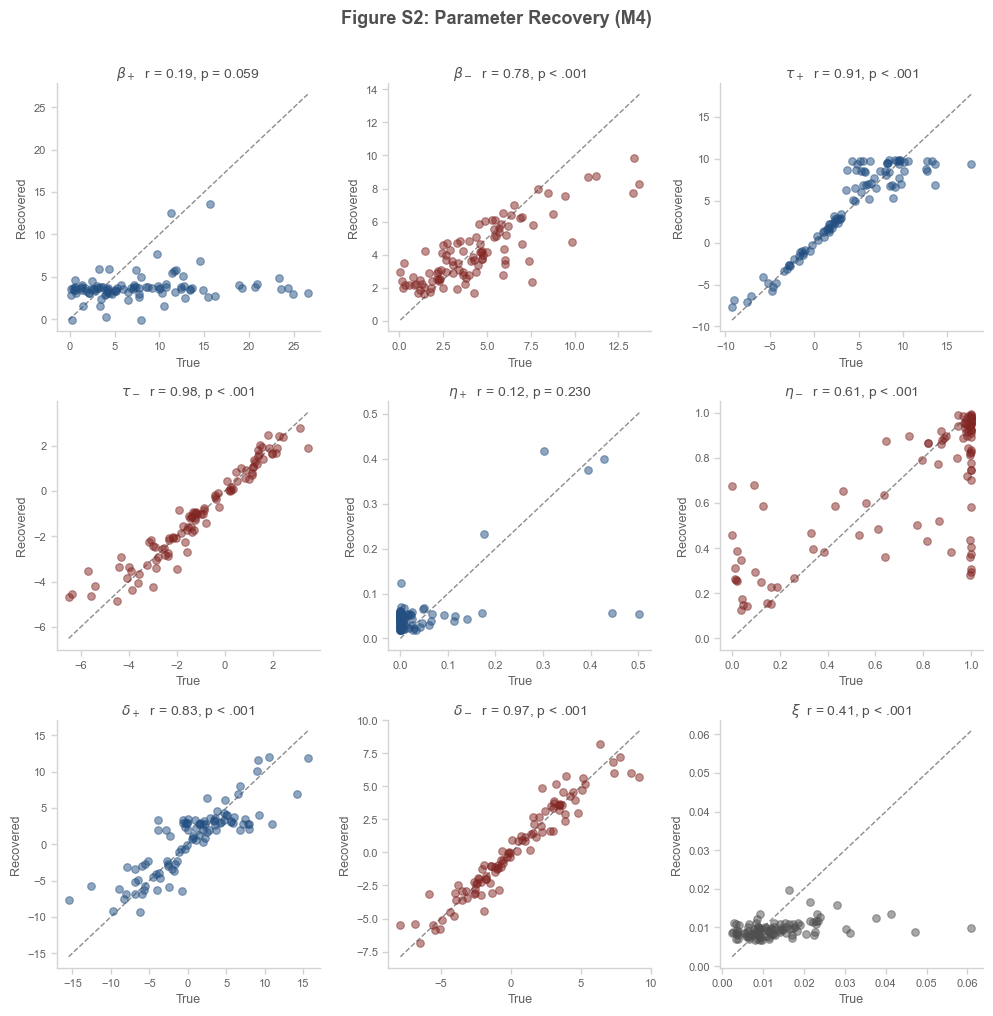

Saved figS2_recovery_m4.png


In [3]:
# Load M4 true and recovered parameters
true      = pd.read_csv(os.path.join(SIM_DIR, 'true_params_pgng_m4.csv'))
recovered = pd.read_csv(os.path.join(RECOVERY_DIR, 'pgng_m4.tsv.gz'),
                        sep='\t', compression='gzip')

params = ['b1', 'b2', 'b3', 'b4', 'a1', 'a2', 'd1', 'd2', 'c1']
labels = [r'$\beta_+$', r'$\beta_-$',
          r'$\tau_+$',  r'$\tau_-$',
          r'$\eta_+$',  r'$\eta_-$',
          r'$\delta_+$',r'$\delta_-$',
          r'$\xi$']
colors = [COLOR_REW, COLOR_PUN,
          COLOR_REW, COLOR_PUN,
          COLOR_REW, COLOR_PUN,
          COLOR_REW, COLOR_PUN,
          COLOR_OTH]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.patch.set_facecolor('white')

for i, (param, label, color) in enumerate(zip(params, labels, colors)):
    ax = axes[i//3, i%3]

    true_vals      = true[param].values
    recovered_vals = recovered.filter(regex=f'{param}\\[').mean(axis=0).values
    r, p           = spearmanr(true_vals, recovered_vals)

    ax.scatter(true_vals, recovered_vals,
               color=color, alpha=0.5, s=30, zorder=3)

    mn = min(true_vals.min(), recovered_vals.min())
    mx = max(true_vals.max(), recovered_vals.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5, zorder=2)

    p_str = f'= {p:.3f}' if p >= .001 else '< .001'
    ax.set_title(f'{label}  r = {r:.2f}, p {p_str}',
                 color=labelcolor, fontsize=10, pad=4)
    ax.set_xlabel('True', color=tickcolor, fontsize=9)
    ax.set_ylabel('Recovered', color=tickcolor, fontsize=9)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.spines['bottom'].set(linewidth=1, color=axiscolor)
    ax.tick_params(color=axiscolor, length=4, width=1,
                   labelcolor=tickcolor, labelsize=8)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

plt.suptitle('Figure S2: Parameter Recovery (M4)', color=labelcolor,
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figS2_recovery_m4.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved figS2_recovery_m4.png')

## 4 — Figure S3: Pairwise correlations between recovered M4 parameters

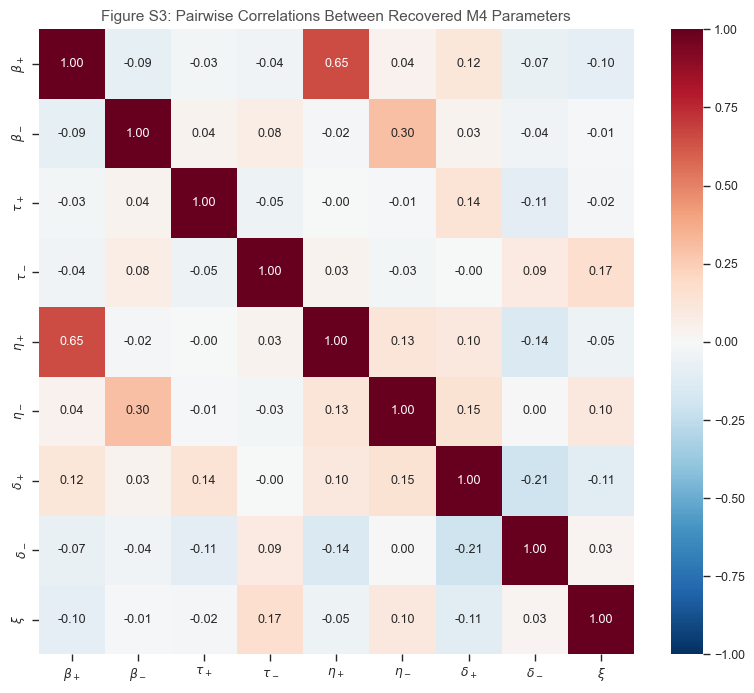

Saved figS3_param_correlations.png

Correlation matrix:
      b1    b2    b3    b4    a1    a2    d1    d2    c1
b1  1.00 -0.09 -0.03 -0.04  0.65  0.04  0.12 -0.07 -0.10
b2 -0.09  1.00  0.04  0.08 -0.02  0.30  0.03 -0.04 -0.01
b3 -0.03  0.04  1.00 -0.05 -0.00 -0.01  0.14 -0.11 -0.02
b4 -0.04  0.08 -0.05  1.00  0.03 -0.03 -0.00  0.09  0.17
a1  0.65 -0.02 -0.00  0.03  1.00  0.13  0.10 -0.14 -0.05
a2  0.04  0.30 -0.01 -0.03  0.13  1.00  0.15  0.00  0.10
d1  0.12  0.03  0.14 -0.00  0.10  0.15  1.00 -0.21 -0.11
d2 -0.07 -0.04 -0.11  0.09 -0.14  0.00 -0.21  1.00  0.03
c1 -0.10 -0.01 -0.02  0.17 -0.05  0.10 -0.11  0.03  1.00


In [4]:
# Extract subject-level posterior means from M4
summary = pd.read_csv(os.path.join(RECOVERY_DIR, 'pgng_m4_summary.tsv'),
                      sep='\t', index_col=0)

param_means = {}
for param in params:
    rows = summary.filter(regex=rf'^{param}\[', axis=0)
    param_means[param] = rows['Mean'].values

df_params   = pd.DataFrame(param_means)
corr_matrix = df_params.corr()

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[PARAM_LABELS[p] for p in params],
            yticklabels=[PARAM_LABELS[p] for p in params],
            ax=ax)
ax.set_title('Figure S3: Pairwise Correlations Between Recovered M4 Parameters',
             fontsize=11, color=labelcolor)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figS3_param_correlations.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved figS3_param_correlations.png')
print('\nCorrelation matrix:')
print(corr_matrix.round(2).to_string())